# PFI Analysis

## Objective

The objective of this notebook is to run the code and see the distribution of PFI values

In [215]:
# Imports 
import numpy as np 
import pandas as pd 
import torch 
import torch.optim as optim 
from pathlib import Path 
import json
import matplotlib.pyplot as plt
import sys
import os

# Adds the project root to the python path
sys.path.append(os.path.abspath(os.path.join('../../')))

# My imports
from src.models.lstm import LSTM 
from src.models.masked_lstm import MaskedLSTM
from src.models.trainer import Trainer
from src.models.masked_trainer import MaskedTrainer
from src.utils.loss_functions import RMSELoss
from src.utils.config_file_parser import config_file_parser
from src.utils.plot_predictions import plot_predictions
from src.utils.plot_losses import plot_loss_curves
from src.utils.datapipeline import DataPipeline
from src.utils.window_sizes.sliding_window_pipeline import SlidingWindowPipeline, SlidingWindowBatch
from src.interpretability.pfi import permutation_feature_importance
from src.interpretability.pfi_plots import plot_pfi_radar, plot_pfi_bar
from src.utils.metric_functions import rmse

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [216]:
county_name = "Kern"
datafile_version = "baseline" # baseline has VFRate, logVF has log1pVFRate
tgt_variable = "VFRate"
rodent_flag = True
drought_flag = True
appendvar = "_fixed" if county_name == "Kern" else ""
# Timestamp to track creation of run data
timestamp = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
config_path = Path("../../config/masked_lstm_config_test.ini")
if rodent_flag and drought_flag:
    data_path  = Path(f"../../data/{county_name.lower()}_agg_drought_{datafile_version}{appendvar}.csv")
    run_dir    = Path(f"../../data/runs/{county_name.lower()}_Rat_Drought_{datafile_version}_{timestamp}")
elif rodent_flag:
  data_path   = Path(f"../../data/merged_rodent_{county_name.lower()}_agg.csv")
  run_dir     = Path(f"../../data/runs/{county_name.lower()}_Rat_{timestamp}")
else:
    data_path  = Path(f"../../data/{county_name.lower()}_Aggregate.csv")
    run_dir    = Path(f"../../data/runs/{county_name.lower()}_noRat_{timestamp}")

run_dir.mkdir(parents=True, exist_ok=True)

# ------------- DO NOT TOUCH BELOW HERE --------------

# load config data
lstm_params, pipeline_params = config_file_parser(config_path=config_path)
hidden_size                  = int(lstm_params["hidden_size"])
num_layers                   = int(lstm_params["num_layers"])
dropout                      = float(lstm_params["dropout"])
learning_rate                = float(lstm_params["learning_rate"])
epochs                       = int(lstm_params["epochs"])
weight_decay                 = float(lstm_params["weight_decay"])
train_frac                   = float(lstm_params["train_frac"])
test_frac                    = 1 - train_frac

# import and clean the dataframe (remove date) 
# and maybe other columns im not interested in
df = pd.read_csv(data_path)
for col in ["YEAR_MONTH", "Year-Month", "DATE"]:
    if col in df.columns:
      df = df.drop(columns = [col])

# Isolate the features I want
feature_columns = [col for col in df.columns if col != tgt_variable]
print(feature_columns)
# Create the feature and target vectors
X = df[feature_columns].values
y = df[tgt_variable].values 

['PRECIP', 'WIND_EventCount', 'WIND_AvgMPH', 'WIND_RunMiles', 'AQI_PM25', 'AQI_PM10', 'EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'Avg_Monthly_DSCI']


In [217]:
# Create the datapipeline for sliding window calculations
pipeline = SlidingWindowPipeline(X, y, test_frac=test_frac)

# create a list of sliding window sizes from 1 to 12
sliding_window_sizes = [x for x in range(1,13)]
criterion = RMSELoss()

results = [] 

for feat_idx, feat_name in enumerate(feature_columns):
  for win_size in sliding_window_sizes:
    batch : SlidingWindowBatch = pipeline.scale(*pipeline.create_single_feature_sequences(feat_idx, win_size))
    
    model = LSTM(
      input_size = 1,
      hidden_size= hidden_size, 
      num_layers= num_layers,
      dropout= dropout
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
    trainer = Trainer(model=model, criterion=criterion, optimizer=optimizer, scaler_y = batch.scaler_y)
    
    trainer.train(
        X_train = batch.X_train.to(device), 
        y_train = batch.y_train.to(device), 
        epochs=epochs)
    preds, true = trainer.evaluate(
        batch.X_test.to(device), 
        batch.y_test.to(device)
        )
    
    rmse_sw = np.sqrt(np.mean((preds - true)**2))
    results.append({
      "feature": feat_name, 
      "window_size": win_size,
      "rmse": rmse_sw
    })
    print(f"{feat_name:20s} | w={win_size:2d} | RMSE = {rmse_sw:.4f}")

results_df = pd.DataFrame(results)
best_vals = results_df.loc[results_df.groupby("feature")["rmse"].idxmin()]

PRECIP               | w= 1 | RMSE = 7.5872
PRECIP               | w= 2 | RMSE = 8.1986
PRECIP               | w= 3 | RMSE = 11.8352
PRECIP               | w= 4 | RMSE = 7.9111
PRECIP               | w= 5 | RMSE = 10.5136
PRECIP               | w= 6 | RMSE = 7.7235
PRECIP               | w= 7 | RMSE = 8.7122
PRECIP               | w= 8 | RMSE = 6.8516
PRECIP               | w= 9 | RMSE = 5.0803
PRECIP               | w=10 | RMSE = 6.9841
PRECIP               | w=11 | RMSE = 9.1305
PRECIP               | w=12 | RMSE = 7.2486
WIND_EventCount      | w= 1 | RMSE = 6.7444
WIND_EventCount      | w= 2 | RMSE = 7.9791
WIND_EventCount      | w= 3 | RMSE = 7.4308
WIND_EventCount      | w= 4 | RMSE = 6.2498
WIND_EventCount      | w= 5 | RMSE = 10.0627
WIND_EventCount      | w= 6 | RMSE = 9.7170
WIND_EventCount      | w= 7 | RMSE = 9.4802
WIND_EventCount      | w= 8 | RMSE = 10.5412
WIND_EventCount      | w= 9 | RMSE = 7.5525
WIND_EventCount      | w=10 | RMSE = 9.9562
WIND_EventCount      | w=11 

In [218]:
best_vals

,feature,window_size,rmse
63,AQI_PM10,4,5.394910
50,AQI_PM25,3,7.839364
108,Avg_Monthly_DSCI,1,3.696476
79,EARTHQUAKE_Total,8,5.874557
85,PESTICIDE_Total,2,7.704178
8,PRECIP,9,5.080283
96,RODENTICIDE_Total,1,6.627137
28,WIND_AvgMPH,5,7.039480
15,WIND_EventCount,4,6.249795
38,WIND_RunMiles,3,5.897346


In [219]:
########################################
#         Masked LSTM Analysis         #
########################################
window_sizes = best_vals

pipeline = DataPipeline(
  data_file_path=data_path,
  config_data = lstm_params,
  window_sizes = window_sizes,
  tgt_variable=tgt_variable
)

pipeline.load_data()
pipeline.build_windows()
dataset = pipeline.scale(*pipeline.split())

mask_batch = dataset.mask.unsqueeze(-1)
mask_batch = mask_batch.permute(2,0,1)

model = MaskedLSTM(
  input_size = dataset.X_train.shape[1],
  hidden_size= hidden_size,
  num_layers= num_layers,
  dropout= dropout
).to(device)

optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay=weight_decay)
criterion = RMSELoss()

trainer = MaskedTrainer(
  model = model, 
  criterion= criterion,
  optimizer= optimizer,
  scaler_y= dataset.scaler_y
)

history = trainer.train(
  X_train = dataset.X_train.permute(2,0,1).to(device),
  y_train = dataset.y_train.to(device),
  X_test= dataset.X_test.permute(2,0,1).to(device),
  y_test=dataset.y_test.to(device),
  mask_train = mask_batch.repeat(dataset.X_train.shape[2], 1, 1).to(device),
  mask_test = mask_batch.repeat(dataset.X_test.shape[2], 1, 1).to(device),
  epochs= epochs
)

preds, true = trainer.evaluate(
  X_test = dataset.X_test.permute(2,0,1).to(device),
  y_test= dataset.y_test.to(device),
  mask= mask_batch.repeat(dataset.X_test.shape[2], 1, 1).to(device)
)

rmse_final = np.sqrt(np.mean((preds - true)**2))
print(f"Final test RMSE: {rmse_final:.4f}")

Epoch:   10 | Train Loss: 0.2007 | Test Loss: 0.1876
Epoch:   20 | Train Loss: 0.1989 | Test Loss: 0.1751
Epoch:   30 | Train Loss: 0.1853 | Test Loss: 0.1763
Epoch:   40 | Train Loss: 0.1459 | Test Loss: 0.1606
Epoch:   50 | Train Loss: 0.1295 | Test Loss: 0.1618
Epoch:   60 | Train Loss: 0.1150 | Test Loss: 0.1604
Epoch:   70 | Train Loss: 0.1038 | Test Loss: 0.1420
Epoch:   80 | Train Loss: 0.0905 | Test Loss: 0.1079
Epoch:   90 | Train Loss: 0.0962 | Test Loss: 0.1505
Epoch:  100 | Train Loss: 0.0969 | Test Loss: 0.1178
Epoch:  110 | Train Loss: 0.0780 | Test Loss: 0.1131
Epoch:  120 | Train Loss: 0.0714 | Test Loss: 0.1289
Final test RMSE: 6.0661


In [220]:
# ----------------------------------------------------
# Compute training predictions
# ----------------------------------------------------
with torch.no_grad():
    train_preds = model(
        dataset.X_train.permute(2,0,1).to(device),
        mask_batch.repeat(dataset.X_train.shape[2], 1, 1).to(device)
    ).cpu().numpy().reshape(-1,1)

train_preds_inv = dataset.scaler_y.inverse_transform(train_preds).flatten()
true_train_inv  = dataset.scaler_y.inverse_transform(dataset.y_train.cpu().numpy().reshape(-1,1)).flatten()

# test preds already computed
pred_test_inv = preds
true_test_inv = true

---- Saving Data ----


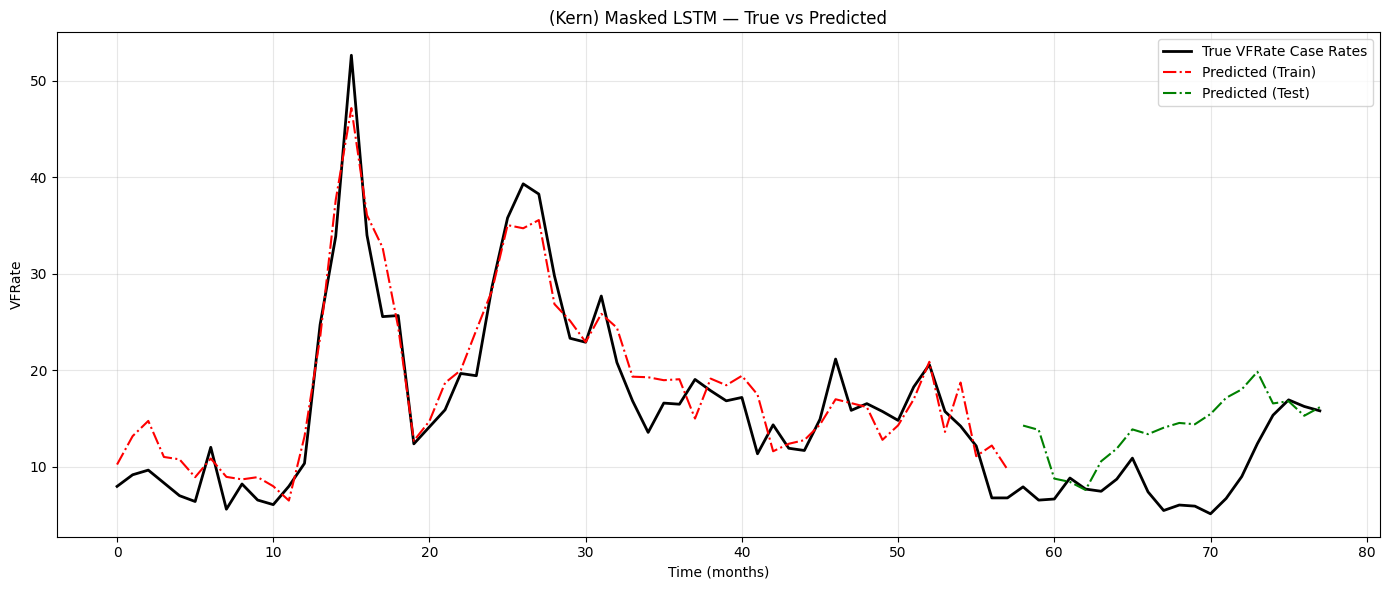

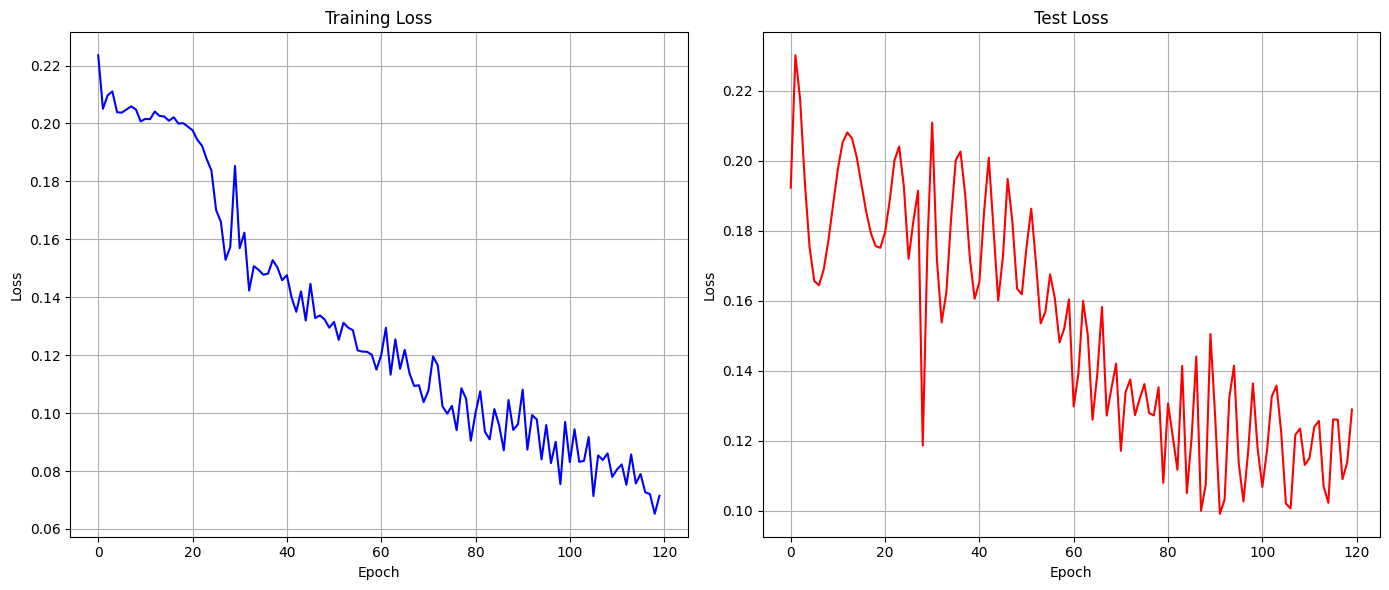

In [221]:
# ----------------------------------------------------
# Plot everything and start saving data
# ----------------------------------------------------
plot_predictions(
    true_train=true_train_inv,
    pred_train=train_preds_inv,
    true_test=true_test_inv,
    pred_test=pred_test_inv,
    tgt_variable = tgt_variable,
    title=f"({county_name}) Masked LSTM — True vs Predicted",
    save_path=run_dir/"prediction_curve.png"
)

# saving data
print("---- Saving Data ----")
params_to_save = {
  "hidden_size" : hidden_size,
  "num_layers" : num_layers, 
  "dropout" : dropout, 
  "learning_rate": learning_rate,
  "epochs" : epochs, 
  "weight_decay" : weight_decay, 
  "train_frac" : train_frac, 
  "test_frac" : test_frac
}

# with open(run_dir / "parameters.json", "w") as f:
#  json.dump(params_to_save, f, indent = 4)

#results_df.to_csv(run_dir/"sliding_window_results.csv", index = False)
#best_vals.to_csv(run_dir/"best_window_sizes.csv", index = False)

# ----- Save Test Predictions -----
test_pred_data = pd.DataFrame({
  "sample_index": np.arange(len(true_test_inv)),
  "true_test": true_test_inv,
  "pred_test": pred_test_inv
})
#test_pred_data.to_csv(run_dir/"true_vs_pred_test.csv", index=False)

# ----- Save Train Predictions -----
train_pred_data = pd.DataFrame({
  "sample_index": np.arange(len(true_train_inv)),
  "true_train": true_train_inv,
  "pred_train": train_preds_inv
})
#train_pred_data.to_csv(run_dir/"true_vs_pred_train.csv", index=False)


# plot and save history curve
plot_loss_curves(history, save_path = run_dir/"loss_curves.png")
# ----- Save Training History -----
history_df = pd.DataFrame({
    "epoch": np.arange(1, len(history["train"]) + 1),
    "train_loss": history["train"],
    "test_loss": history["test"]
})
#history_df.to_csv(run_dir/"training_history.csv", index=False)

             Feature  Importance  window_size
0             PRECIP    0.270060            9
1    WIND_EventCount    0.276031            4
2        WIND_AvgMPH   -0.261049            5
3      WIND_RunMiles   -0.303360            3
4           AQI_PM25    0.530125            3
5           AQI_PM10    1.188976            4
6   EARTHQUAKE_Total    0.192732            8
7    PESTICIDE_Total   -0.308538            2
8  RODENTICIDE_Total    0.049070            1
9   Avg_Monthly_DSCI    7.414236            1


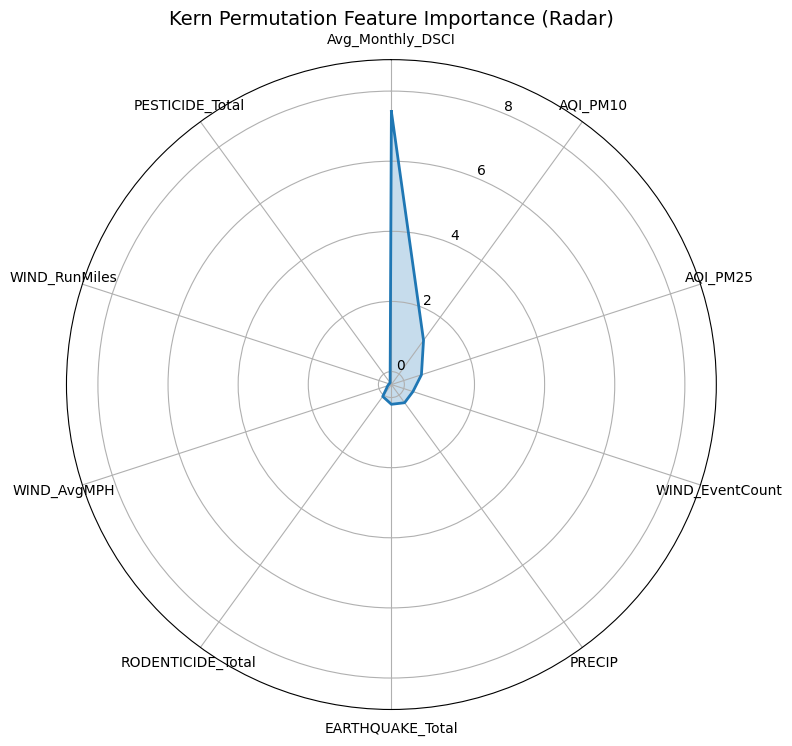

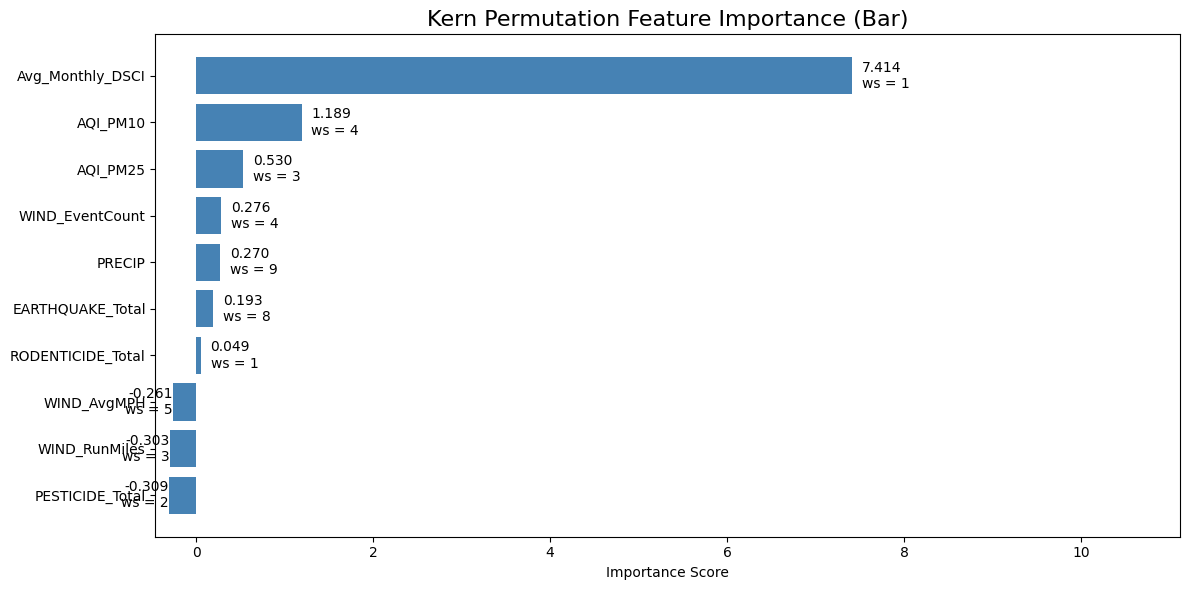

In [222]:
if bool(pipeline_params["run_pfi"]):
    importances, baseline_error, all_results = permutation_feature_importance(model = model,
                                                                X_test = dataset.X_test.permute(2,0,1).to(device),
                                                                y_test = dataset.y_test.to(device),
                                                                mask = mask_batch.repeat(dataset.X_test.shape[2], 1, 1).to(device),
                                                                scaler_y = dataset.scaler_y,
                                                                metric_fn = rmse,
                                                                n_repeats = 1000
                                                                )

pfi_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importances
})

pfi_df["key"] = pfi_df["Feature"].str.lower()
window_sizes["key"] = window_sizes["feature"].str.lower()

pfi_df_merged = pfi_df.merge(
    window_sizes[["key", "feature", "window_size"]],
    on="key",
    how="inner"
)
pfi_df_merged.drop(columns=["key"])

pfi_df = pfi_df_merged[["Feature", "Importance", "window_size"]]
print(pfi_df)
# pfi_df.to_csv(run_dir/"pfi_importance.csv", index = False)

plot_pfi_radar(pfi_df, title=f"{county_name} Permutation Feature Importance (Radar)")

plot_pfi_bar(pfi_df, title=f"{county_name} Permutation Feature Importance (Bar)")

# plot_pfi_boxplot(all_results, pfi_df, save_path = run_dir/"pfi_boxplot.png", title = f"{county_name} Permutation Feature Importance (Boxplot)")

plt.show()

In [223]:
print(feature_columns)
print(all_results.shape)
valsDict = dict()
count = 0
for feat in feature_columns:
  valsDict[feat] = all_results[count, :]
  count += 1

['PRECIP', 'WIND_EventCount', 'WIND_AvgMPH', 'WIND_RunMiles', 'AQI_PM25', 'AQI_PM10', 'EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'Avg_Monthly_DSCI']
(10, 1000)


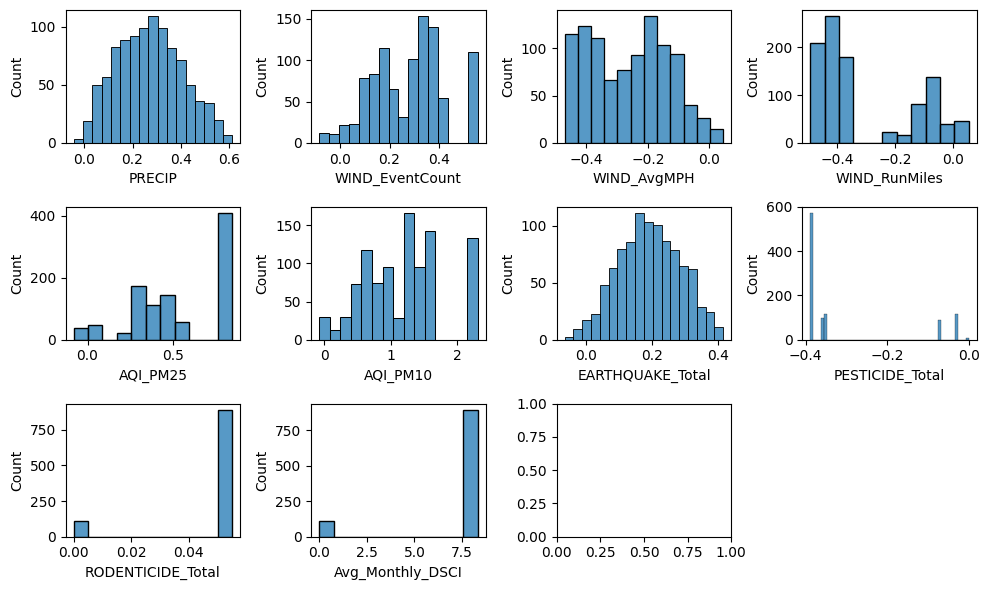

In [224]:
import seaborn as sns
count = 0
fig, axes = plt.subplots(3,4,figsize=(10,6))
axes = axes.flatten()

for feat in feature_columns:
  sns.histplot(data=valsDict, x = feat, ax = axes[count])
  count += 1
  
axes[-1].axis('off')
plt.tight_layout()
plt.show()